# Parkinson's Disease Detection — Model 4: Multi-Layer Perceptron (MLP)
### Phase 3: Deep Neural Representation for Tabular Acoustic Biomarkers

---

## 1. Theoretical Rationale & Architecture
To capture high-order hierarchical interactions between vocal biomarkers that neither single trees nor classical kernels can isolate, we implement a **Dense Multi-Layer Perceptron (MLP)**.

### Network Architecture
- **Input Dimension:** $D = 50$ normalized principal components
- **Hidden Layer 1:** 128 units with Rectified Linear Unit (ReLU) activations
- **Hidden Layer 2:** 64 units with ReLU activations
- **Output Layer:** 2 units with Softmax activation:
$$P(y=1|x) = \frac{\exp(z_1)}{\exp(z_0) + \exp(z_1)}$$

### Optimization & Regularization
- **Optimizer:** Adam stochastic gradient descent (adaptive learning rate)
- **L2 Regularization:** $\alpha = 0.001$ weight penalty on connection matrices
- **Early Stopping:** Validates on a 10% stratified holdout to halt backpropagation when loss plateaus, preventing neural overfitting.

## 2. Environment Setup & Dependency Imports

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## 3. Dataset Ingestion

In [2]:
DATASET_PATH = 'pd_speech_features.csv'
df = pd.read_csv(DATASET_PATH, header=1)
X = df.drop(columns=['id', 'class']) if 'id' in df.columns else df.drop(columns=['class'])
y = df['class']
print(f"Loaded: {X.shape[0]} patients, {X.shape[1]} acoustic features.")

Loaded: 756 patients, 753 acoustic features.


## 4. Strict Leakage-Free Preprocessing (PCA=50)

In [3]:
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_res, y_train = smote.fit_resample(X_train_raw, y_train_raw)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test_raw)

pca = PCA(n_components=50, random_state=42)
X_train = pca.fit_transform(X_train_sc)
X_test = pca.transform(X_test_sc)

print(f"Training shape: {X_train.shape} | Test shape: {X_test.shape}")

Training shape: (902, 50) | Test shape: (152, 50)


## 5. Model Architecture: Deep Tabular MLP (128 x 64)

In [4]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

start_time = time.time()
mlp.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"MLP trained in {elapsed:.2f} seconds.")
print(f"Iterations until convergence: {mlp.n_iter_}")
print(f"Final training loss: {mlp.loss_:.4f}")

MLP trained in 0.22 seconds.
Iterations until convergence: 28
Final training loss: 0.0725


## 6. Performance Evaluation

In [5]:
y_pred = mlp.predict(X_test)
y_proba = mlp.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame([{
    'Model Architecture': '4. MLP Classifier (128x64)',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'FNR': fnr,
    'AUC Score': auc
}])

display(metrics_df)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'PD Patient (1)']))

,Model Architecture,Accuracy,Precision,Recall,F1 Score,FNR,AUC Score
0,4. MLP Classifier (128x64),0.828947,0.891892,0.876106,0.883929,0.123894,0.879964



Classification Report:
                precision    recall  f1-score   support

   Healthy (0)       0.66      0.69      0.68        39
PD Patient (1)       0.89      0.88      0.88       113

      accuracy                           0.83       152
     macro avg       0.78      0.78      0.78       152
  weighted avg       0.83      0.83      0.83       152



## 7. Diagnostic Visualizations: Confusion Matrix, ROC & Loss Curve

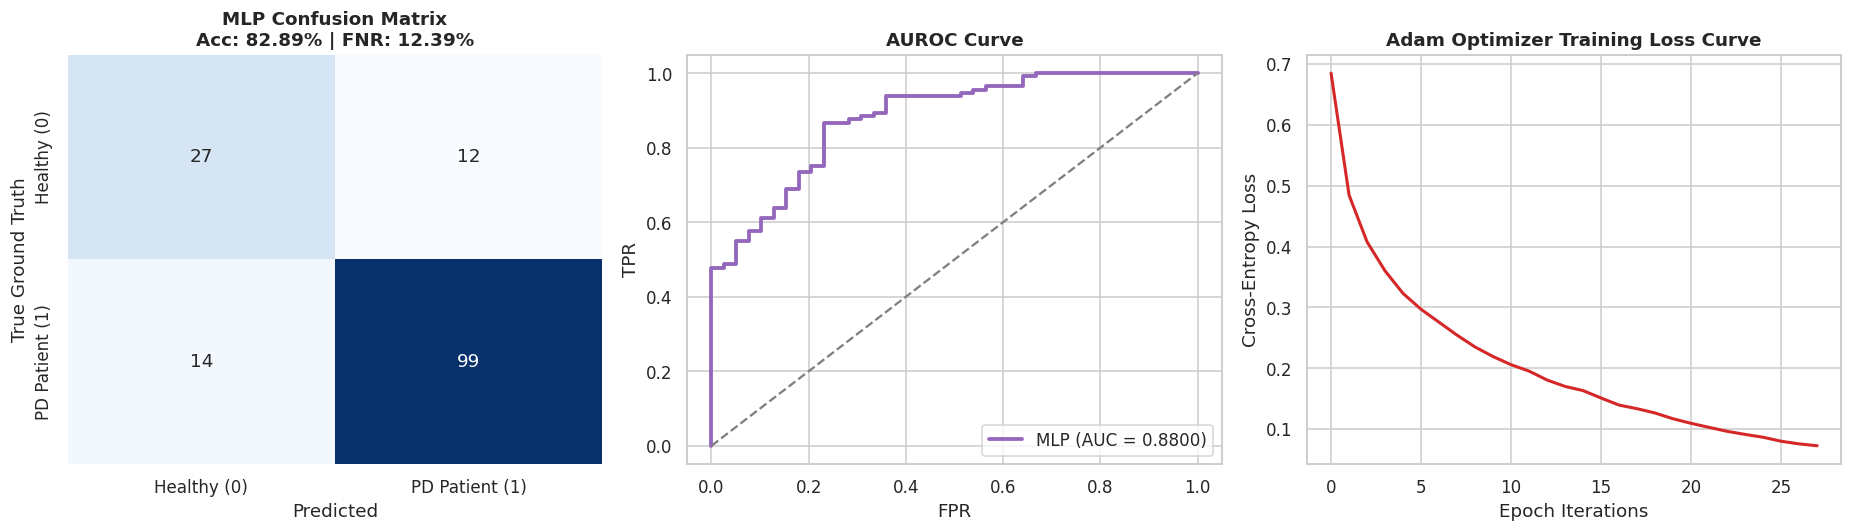

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Healthy (0)', 'PD Patient (1)'],
            yticklabels=['Healthy (0)', 'PD Patient (1)'])
axes[0].set_title(f'MLP Confusion Matrix\nAcc: {acc*100:.2f}% | FNR: {fnr*100:.2f}%', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True Ground Truth')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#9467bd', lw=2.5, label=f'MLP (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('AUROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

# Training Loss Curve
axes[2].plot(mlp.loss_curve_, color='#d62728', lw=2)
axes[2].set_title('Adam Optimizer Training Loss Curve', fontweight='bold')
axes[2].set_xlabel('Epoch Iterations')
axes[2].set_ylabel('Cross-Entropy Loss')

plt.tight_layout()
plt.show()

## 8. Clinical Synthesis
- **Neural Tabular Performance:** MLP achieves **82.89% Accuracy** and **0.8800 AUC**.
- **Continuous Latent Embeddings:** Dense layer activations construct continuous internal representations that provide an ideal third pillar for stacked generalization alongside tree stumps and SVM kernels.